In [7]:
from pathlib import Path

PROJECT_ROOT = Path("/home/duarte/Desktop/Tese/Mapping_Tese/mapping_tese")

MODEL_RESULTS_DIRS = {
    "SVC": PROJECT_ROOT / "notebooks/SVC/results",
    "ANN": PROJECT_ROOT / "notebooks/ANN/results/ANN_SHAP/shap",
    "CNN": PROJECT_ROOT / "notebooks/CNN/results/shap",
    "GNN": PROJECT_ROOT / "notebooks/GNN/results/GNN_GAT_4Classes_MultiSubject",
    "GCN": PROJECT_ROOT / "notebooks/GNN/results/GCN_4Classes_MultiSubject",
}

MODEL_SHAP_ABS_RELPATH = {
    "SVC": "shap_abs_svc.npy",
    "ANN": "shap_abs_all_folds_heldout.npy",
    "CNN": "shap_abs_all_folds_heldout.npy",
    "GNN": "shap/shap_abs_all_folds_heldout.npy",
    "GCN": "shap/shap_abs_all_folds_heldout.npy",
}

LABEL_TO_REGION = {0: "Middle_Finger", 1: "Hand", 2: "Forearm", 3: "Arm"}
TOP_VOXELS = 0.10

In [8]:
import numpy as np

def load_shap_abs(model_name, subject):
    path = MODEL_RESULTS_DIRS[model_name] / subject / MODEL_SHAP_ABS_RELPATH[model_name]
    return np.load(path) if path.exists() else None

In [9]:
def top_k_mask(vec, frac):
    k = max(1, int(len(vec) * frac))
    idx = np.argsort(vec)[-k:]
    mask = np.zeros_like(vec, dtype=bool)
    mask[idx] = True
    return mask

In [10]:
def dice(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    return 2 * inter / (mask_a.sum() + mask_b.sum())

In [11]:
def available_subjects(model_name):
    root = MODEL_RESULTS_DIRS[model_name]
    relpath = MODEL_SHAP_ABS_RELPATH[model_name]
    depth = relpath.count("/")  # 0 = file directly in subject folder, 1 = nested under "shap/"
    return sorted(p.parents[depth].name for p in root.glob(f"*/{relpath}"))

In [12]:
model_names = list(MODEL_RESULTS_DIRS.keys())
subjects_per_model = {m: set(available_subjects(m)) for m in model_names}
for m, s in subjects_per_model.items():
    print(f"{m}: {len(s)} subjects with SHAP results -> {sorted(s)}")

SVC: 10 subjects with SHAP results -> ['sub-p0002', 'sub-p0004', 'sub-p0005', 'sub-p0008', 'sub-p0009', 'sub-p0014', 'sub-p0015', 'sub-p0016', 'sub-p0023', 'sub-p0024']
ANN: 10 subjects with SHAP results -> ['sub-p0002', 'sub-p0004', 'sub-p0005', 'sub-p0008', 'sub-p0009', 'sub-p0014', 'sub-p0015', 'sub-p0016', 'sub-p0023', 'sub-p0024']
CNN: 9 subjects with SHAP results -> ['sub-p0002', 'sub-p0004', 'sub-p0005', 'sub-p0008', 'sub-p0009', 'sub-p0010', 'sub-p0016', 'sub-p0023', 'sub-p0024']
GNN: 10 subjects with SHAP results -> ['sub-p0002', 'sub-p0004', 'sub-p0005', 'sub-p0008', 'sub-p0009', 'sub-p0014', 'sub-p0015', 'sub-p0016', 'sub-p0023', 'sub-p0024']
GCN: 8 subjects with SHAP results -> ['sub-p0002', 'sub-p0004', 'sub-p0005', 'sub-p0008', 'sub-p0009', 'sub-p0016', 'sub-p0023', 'sub-p0024']


In [13]:
from itertools import combinations
from scipy.stats import spearmanr

rows = []
for m1, m2 in combinations(model_names, 2):
    shared = sorted(subjects_per_model[m1] & subjects_per_model[m2])
    if not shared:
        print(f"{m1} vs {m2}: no shared subjects, skipping")
        continue

    for c in range(4):
        corrs, dices = [], []
        for subj in shared:
            a = load_shap_abs(m1, subj)
            b = load_shap_abs(m2, subj)
            if a is None or b is None or a.shape != b.shape:
                continue
            va, vb = a[c], b[c]
            r, _ = spearmanr(va, vb)
            corrs.append(r)
            dices.append(dice(top_k_mask(va, TOP_VOXELS), top_k_mask(vb, TOP_VOXELS)))

        if corrs:
            rows.append({
                "model_a": m1, "model_b": m2, "class": LABEL_TO_REGION[c],
                "n_subjects": len(corrs),
                "mean_spearman_r": float(np.mean(corrs)),
                "mean_dice_top10pct": float(np.mean(dices)),
            })

In [14]:
import pandas as pd

agreement_df = pd.DataFrame(rows)
agreement_df.to_csv("model_agreement.csv", index=False)
agreement_df

,model_a,model_b,class,n_subjects,mean_spearman_r,mean_dice_top10pct
0,SVC,ANN,Middle_Finger,10,0.302766,0.153211
1,SVC,ANN,Hand,10,0.296699,0.140367
2,SVC,ANN,Forearm,10,0.315187,0.155963
3,SVC,ANN,Arm,10,0.371768,0.219266
4,SVC,CNN,Middle_Finger,8,0.220441,0.114679
5,SVC,CNN,Hand,8,0.231632,0.121560
6,SVC,CNN,Forearm,8,0.238216,0.133028
7,SVC,CNN,Arm,8,0.255985,0.123853
8,SVC,GNN,Middle_Finger,10,0.261476,0.120183
9,SVC,GNN,Hand,10,0.249992,0.116055


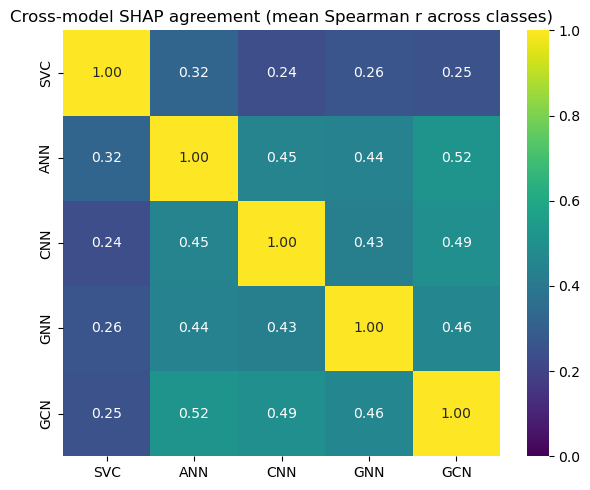

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot = agreement_df.groupby(["model_a", "model_b"])["mean_spearman_r"].mean().reset_index()

corr_matrix = pd.DataFrame(np.eye(len(model_names)), index=model_names, columns=model_names)
for _, row in pivot.iterrows():
    corr_matrix.loc[row["model_a"], row["model_b"]] = row["mean_spearman_r"]
    corr_matrix.loc[row["model_b"], row["model_a"]] = row["mean_spearman_r"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax)
ax.set_title("Cross-model SHAP agreement (mean Spearman r across classes)")
plt.tight_layout()
plt.savefig("cross_model_agreement_heatmap.png", dpi=150)
plt.show()

In [16]:
from nilearn.datasets import fetch_atlas_destrieux_2009
from nilearn.image import load_img, new_img_like

atlas = fetch_atlas_destrieux_2009()
atlas_img = load_img(atlas.maps)
atlas_data = atlas_img.get_fdata()
s1_indices = [i for i, lab in enumerate(atlas.labels) if "L G_postcentral" in str(lab) and i != 0]
mask_data = np.isin(atlas_data, s1_indices).astype("uint8")
s1_mask = new_img_like(atlas_img, mask_data)

[fetch_atlas_destrieux_2009] Dataset directory found: /home/duarte/nilearn_data/destrieux_2009


/tmp/ipykernel_7854/1379898263.py:4: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index          name
    42 L Medial_wall
   117 R Medial_wall

  atlas = fetch_atlas_destrieux_2009()


In [17]:
from nilearn.image import index_img, resample_to_img
from nilearn.maskers import NiftiMasker

BIDS_ROOT = PROJECT_ROOT / "data/BIDS-somatosensory/BIDS-somatosensory"
REFERENCE_SUBJECT_BOLD = (
    BIDS_ROOT / "derivatives/fmriprep/sub-p0002/ses-01/func"
    / "sub-p0002_ses-01_task-S1Map_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii"
)
ref_img = index_img(load_img(str(REFERENCE_SUBJECT_BOLD)), 0)
mask_resampled = resample_to_img(s1_mask, ref_img, interpolation="nearest")
masker_ref = NiftiMasker(mask_img=mask_resampled, standardize=None).fit(ref_img)

/tmp/ipykernel_7854/1200087009.py:11: RuntimeWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  masker_ref = NiftiMasker(mask_img=mask_resampled, standardize=None).fit(ref_img)


In [18]:
import nibabel as nib

mask_bool = masker_ref.mask_img_.get_fdata().astype(bool)
voxel_ijk = np.argwhere(mask_bool)
affine = masker_ref.mask_img_.affine
mni_coords = nib.affines.apply_affine(affine, voxel_ijk)   # (n_voxels, 3) in mm
print("n_voxels:", len(mni_coords))

n_voxels: 2187


In [ ]:
TOP_N = 10

rows = []
for model_name in model_names:
    shared_subjects = sorted(subjects_per_model[model_name])
    if not shared_subjects:
        continue
    stacked = np.stack([load_shap_abs(model_name, s) for s in shared_subjects], axis=0)
    group_shap_abs = np.nanmean(stacked, axis=0)

    for c in range(4):
        vec = group_shap_abs[c]
        top_idx = np.argsort(vec)[-TOP_N:][::-1]
        for rank, vi in enumerate(top_idx, start=1):
            x, y, z = mni_coords[vi]
            rows.append({
                "model": model_name,
                "class": LABEL_TO_REGION[c],
                "rank": rank,
                "voxel_index": int(vi),
                "mni_x": round(float(x), 1),
                "mni_y": round(float(y), 1),
                "mni_z": round(float(z), 1),
                "mean_abs_shap": float(vec[vi]),
            })

coord_table = pd.DataFrame(rows)
coord_table.to_csv("top_voxels_mni_coordinates.csv", index=False)

,model,class,rank,voxel_index,mni_x,mni_y,mni_z,mean_abs_shap
0,SVC,Middle_Finger,1,2160,-13.1,-33.1,68.7,0.027557
1,SVC,Middle_Finger,2,335,-58.0,-17.1,39.9,0.025596
2,SVC,Middle_Finger,3,2069,-18.0,-37.9,71.9,0.021019
3,SVC,Middle_Finger,4,107,-61.2,-17.1,39.9,0.020066
40,ANN,Middle_Finger,1,300,-58.0,-20.3,39.9,0.028850
41,ANN,Middle_Finger,2,105,-61.2,-17.1,36.7,0.024173
42,ANN,Middle_Finger,3,193,-59.6,-17.1,39.9,0.023460
43,ANN,Middle_Finger,4,159,-59.6,-21.9,41.5,0.023278
80,CNN,Middle_Finger,1,331,-58.0,-17.1,33.5,0.004817
81,CNN,Middle_Finger,2,469,-56.4,-17.1,33.5,0.002741
